In [1]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from matching import build_roma_matcher, match_two_images_roma
import viz
import raft_stereo

In [2]:
K_rgb_left = np.array([
    [889.81741800, 0.0, 375.16051052],
    [0.0, 891.25501167, 277.33320298],
    [0.0, 0.0, 1.0]
])
d_rgb_left = np.array([-0.20879479, 0.14454576, -0.00018156, 0.00030712])

K_rgb_right = np.array([
    [889.44722255, 0.0, 365.30215844],
    [0.0, 890.67612482, 285.76081066],
    [0.0, 0.0, 1.0]
])
d_rgb_right = np.array([-0.20743818, 0.14175898, 0.00112518, -0.00010317])

q_1_0 = np.array([0.01308697, -0.0132229, -0.00458315, 0.99981642])
t_1_0 = np.array([0.32019253, 0.00262298, -0.00700941])

# --- IR Intrinsics (Left IR / ir1.png) ---
K_ir_left = np.array([
    [513.16931123, 0.0, 334.41296733],
    [0.0, 512.31686524, 245.59631314],
    [0.0, 0.0, 1.0]
])
d_ir_left = np.array([-0.44115841, 0.18764838, 0.00175775, -0.00372122])

In [3]:
img_rgb_path = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam1_image_raw/1.png"
img_ir_path  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_boson_camera_array_cam_1_image_raw/1.png"

matcher_api = build_roma_matcher()

*****************cuda, False**************************


/home/nail/miniconda3/envs/gtsam-env/lib/python3.10/site-packages/pytorch_lightning/profiler/__init__.py:36: LightningDeprecationWarning: `pytorch_lightning.profiler.PassThroughProfiler` is deprecated in v1.9.0 and will be removed in v2.0.0. Use the equivalent `pytorch_lightning.profilers.PassThroughProfiler` class instead.
  rank_zero_deprecation(
2025-12-08 07:44:14.812 | INFO     | MatchAnything.src.lightning.lightning_loftr:__init__:76 - Load model from:<All keys matched successfully>
[2025/12/08 07:44:14 hloc INFO] Loading matchanything_roma model done


[2025/12/08 06:26:55 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 06:26:55 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


Using inlier keypoints (mmkeypoints*_orig).
[INFO] Inliers OK: 872 (limit=3000)
Found 872 matches.


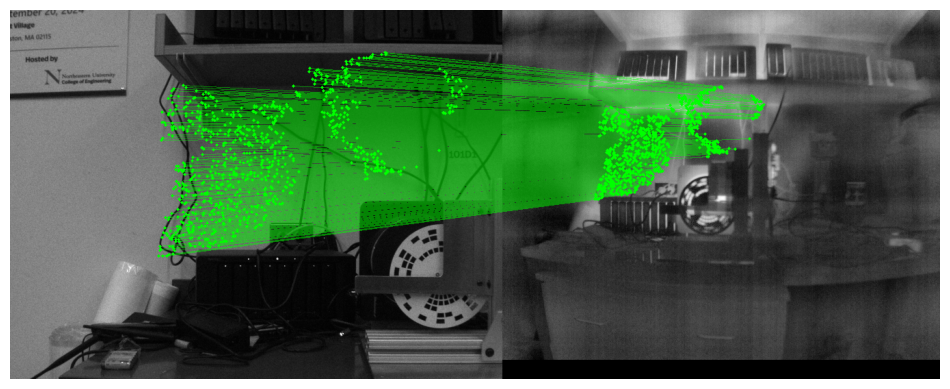

array([[[137, 137, 137],
        [141, 141, 141],
        [138, 138, 138],
        ...,
        [102, 102, 102],
        [110, 110, 110],
        [115, 115, 115]],

       [[136, 136, 136],
        [119, 119, 119],
        [127, 127, 127],
        ...,
        [110, 110, 110],
        [105, 105, 105],
        [ 95,  95,  95]],

       [[ 96,  96,  96],
        [ 92,  92,  92],
        [125, 125, 125],
        ...,
        [113, 113, 113],
        [105, 105, 105],
        [120, 120, 120]],

       ...,

       [[116, 116, 116],
        [122, 122, 122],
        [122, 122, 122],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[122, 122, 122],
        [118, 118, 118],
        [121, 121, 121],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[118, 118, 118],
        [112, 112, 112],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [4]:
mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray = match_two_images_roma(
    matcher_api, img_rgb_path, img_ir_path, max_inliers=3000
)
print(f"Found {len(mkpts_rgb)} matches.")

viz.visualize_matches(rgb_gray, ir_gray, mkpts_rgb, mkpts_ir)


F-Matrix Inliers: 383 matches.
Visualizing epipolar lines...


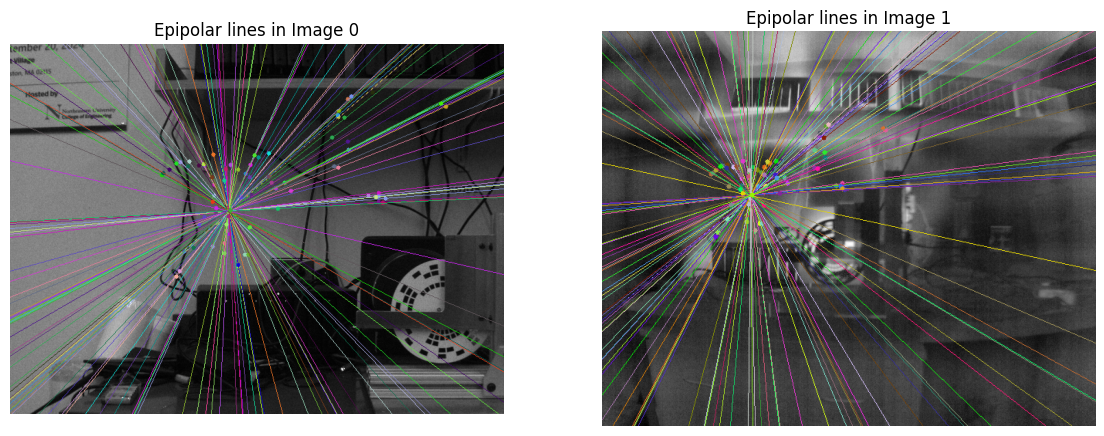

(array([[[137, 137, 137],
         [141, 141, 141],
         [138, 138, 138],
         ...,
         [ 23,  23,  23],
         [ 23,  23,  23],
         [ 24,  24,  24]],
 
        [[136, 136, 136],
         [119, 119, 119],
         [127, 127, 127],
         ...,
         [ 21,  21,  21],
         [ 16,  16,  16],
         [ 25,  25,  25]],
 
        [[ 96,  96,  96],
         [ 92,  92,  92],
         [125, 125, 125],
         ...,
         [ 19,  19,  19],
         [ 22,  22,  22],
         [ 19,  19,  19]],
 
        ...,
 
        [[116, 116, 116],
         [122, 122, 122],
         [122, 122, 122],
         ...,
         [ 73,  73,  73],
         [ 65,  65,  65],
         [ 67,  67,  67]],
 
        [[122, 122, 122],
         [118, 118, 118],
         [121, 121, 121],
         ...,
         [ 80,  80,  80],
         [ 80,  80,  80],
         [ 77,  77,  77]],
 
        [[118, 118, 118],
         [112, 112, 112],
         [ 79, 120, 209],
         ...,
         [ 93,  93,  93],
  

In [5]:
F, mask = cv2.findFundamentalMat(mkpts_rgb, mkpts_ir, cv2.FM_RANSAC, 0.5, 0.999)
# Filter points to just the inliers of the Fundamental Matrix
mask = mask.ravel().astype(bool)
mkpts_rgb_in = mkpts_rgb[mask]
mkpts_ir_in = mkpts_ir[mask]
print(f"F-Matrix Inliers: {len(mkpts_rgb_in)} matches.")
# 6. Draw Epipolar Lines
print("Visualizing epipolar lines...")
# shows the epipolar lines for the inlier points
viz.show_epipolar_lines(rgb_gray, ir_gray, mkpts_rgb_in, mkpts_ir_in, F, sample_step=5)


Calculated Baseline: 0.3203 m
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 6.000 pixels


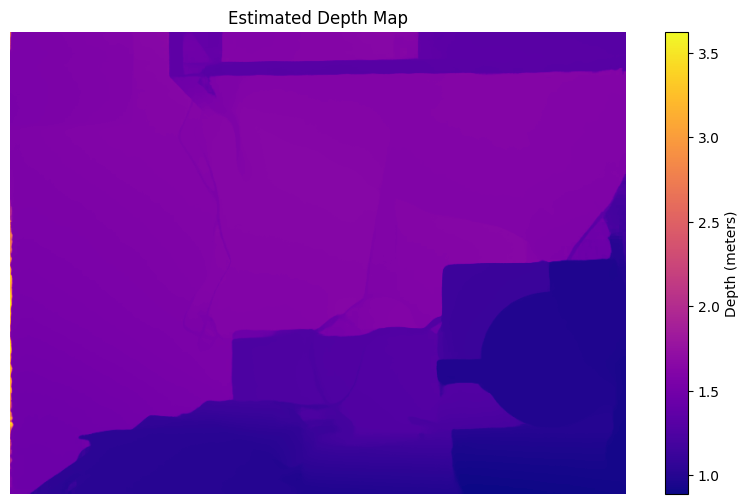

[Point Cloud] Displaying 38863 points (Original: 388800)


In [4]:
img_path_left  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam1_image_raw/1.png"
img_path_right = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam0_image_raw/1.png"
model_weights  = '/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/RAFT-Stereo/models/raftstereo-middlebury.pth'

model = raft_stereo.load_raft_model(model_weights)

img_size = (720, 540) # (W, H)
preprocessor = raft_stereo.StereoPreprocessor(
    K_rgb_left, d_rgb_left, 
    K_rgb_right, d_rgb_right, 
    q_1_0, t_1_0, 
    img_size
)
print(f"Calculated Baseline: {preprocessor.extrinsics['baseline']:.4f} m")

raw_left = cv2.imread(img_path_left)
raw_right = cv2.imread(img_path_right)

preprocessor.auto_align(raw_left, raw_right)

rect_left, rect_right = preprocessor.rectify_images(raw_left, raw_right)

depth_map = raft_stereo.estimate_stereo_depth(
    rect_left, 
    rect_right, 
    model, 
    preprocessor.intrinsics, 
    preprocessor.extrinsics
)
depth_map = np.abs(depth_map) # Ensure positive

viz.plot_depth_map(depth_map)   
# viz.plot_point_cloud(depth_map, preprocessor.intrinsics, preprocessor.extrinsics)

pts3d = viz.backproject_depth(depth_map, preprocessor.intrinsics)
viz.plot_point_cloud(pts3d, rect_left, min_z=0.5, max_z=3.0, subsample=10)